In [53]:
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


from paths import *
from reshandler import DictResHandler

In [54]:
def plot_many_matplotlib_errbar(arrs, labels, save_path, plot_label_dict=None, y_range=None):
    """
    Plots a bar plot with error bars using matplotlib, with labels as the x-axis.

    Parameters:
    - arrs: List of 2D arrays, where each array is (num_samples, num_steps).
    - labels: List of labels for each dataset.
    - save_path: Path to save the resulting plot image.
    - plot_label_dict: Dictionary with 'xlabel', 'ylabel', and 'title' for the plot.
    - y_range: Optional tuple specifying the y-axis range.
    """
    if plot_label_dict is None:
        plot_label_dict = {"xlabel": "Labels", "ylabel": "Mean Value", "title": "Mean Values with Confidence Intervals"}
    
    mean_values = []
    ci_95s = []
    
    # Calculate means and confidence intervals for each label
    for arr in arrs:
        mean_val = np.mean(arr)
        sem_val = stats.sem(arr.flatten())
        ci_95 = 1.96 * sem_val  # 95% confidence interval
        mean_values.append(mean_val)
        ci_95s.append(ci_95)

    # Generate the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    x_positions = np.arange(len(labels))
    
    # Plot bars with error bars
    ax.bar(x_positions, mean_values, yerr=ci_95s, alpha=0.8, capsize=5, color='skyblue', edgecolor='black')
    
    # Customize plot
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, rotation=75)
    ax.set_xlabel(plot_label_dict["xlabel"])
    ax.set_ylabel(plot_label_dict["ylabel"])
    ax.set_title(plot_label_dict["title"])
    
    if y_range:
        ax.set_ylim(y_range)

    # Save and display
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()



def plot_grouped_bar_errbar(arrs_list, labels, save_path, test_names, plot_label_dict=None, y_range=None):
    """
    Plots grouped bar plots with error bars for multiple tests.

    Parameters:
    - arrs_list: List of lists of 2D arrays. Each inner list contains results for one test across different layers.
    - labels: List of layer names.
    - save_path: Path to save the resulting plot image.
    - test_names: List of test names, corresponding to arrs_list.
    - plot_label_dict: Dictionary with 'xlabel', 'ylabel', and 'title' for the plot.
    - y_range: Optional tuple specifying the y-axis range.
    """
    if plot_label_dict is None:
        plot_label_dict = {"xlabel": "Layers", "ylabel": "Mean Value", "title": "Mean Values with Confidence Intervals"}
    
    num_tests = len(arrs_list)
    num_layers = len(labels)
    bar_width = 0.2  # Width of each bar
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, num_tests))  # Generate distinct colors

    # Compute mean values and confidence intervals
    mean_values = []
    ci_95s = []
    
    for test_arrs in arrs_list:
        test_means = []
        test_cis = []
        for arr in test_arrs:
            mean_val = np.mean(arr)
            sem_val = stats.sem(arr.flatten())
            ci_95 = 1.96 * sem_val  # 95% confidence interval
            test_means.append(mean_val)
            test_cis.append(ci_95)
        mean_values.append(test_means)
        ci_95s.append(test_cis)

    # Plot grouped bars
    fig, ax = plt.subplots(figsize=(12, 6))
    x_positions = np.arange(num_layers)

    for i, (means, cis, color, test_name) in enumerate(zip(mean_values, ci_95s, colors, test_names)):
        ax.bar(x_positions + i * bar_width, means, yerr=cis, capsize=5, 
               width=bar_width, color=color, edgecolor='black', label=test_name, alpha=0.8)

    # Customize plot
    ax.set_xticks(x_positions + (num_tests - 1) * bar_width / 2)
    ax.set_xticklabels(labels, rotation=75)
    ax.set_xlabel(plot_label_dict["xlabel"])
    ax.set_ylabel(plot_label_dict["ylabel"])
    ax.set_title(plot_label_dict["title"])
    ax.legend()

    if y_range:
        ax.set_ylim(y_range)

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()


import textwrap

def wrap_labels(labels, max_width=10):
    """Wraps long labels to fit within a given width."""
    return ['\n'.join(textwrap.wrap(label, max_width)) for label in labels]

def plot_grouped_bar_errbar_wrap(arrs_list, labels, save_path, test_names, plot_label_dict=None, y_range=None, max_width=10):
    """
    Plots grouped bar plots with error bars for multiple tests.

    Parameters:
    - arrs_list: List of lists of 2D arrays. Each inner list contains results for one test across different layers.
    - labels: List of layer names.
    - save_path: Path to save the resulting plot image.
    - test_names: List of test names, corresponding to arrs_list.
    - plot_label_dict: Dictionary with 'xlabel', 'ylabel', and 'title' for the plot.
    - y_range: Optional tuple specifying the y-axis range.
    """
    if plot_label_dict is None:
        plot_label_dict = {"xlabel": "Layers", "ylabel": "Mean Value", "title": "Mean Values with Confidence Intervals"}
    
    num_tests = len(arrs_list)
    num_layers = len(labels)
    bar_width = 0.2  # Width of each bar
    # colors = plt.cm.viridis(np.linspace(0.2, 0.8, num_tests))  # Generate distinct colors
    colors = ["#1a80bb", "#ea801c"]
    # colors = ["blue", "orange"]

    # Compute mean values and confidence intervals
    mean_values = []
    ci_95s = []
    
    for test_arrs in arrs_list:
        test_means = []
        test_cis = []
        for arr in test_arrs:
            mean_val = np.mean(arr)
            sem_val = stats.sem(arr.flatten())
            ci_95 = 1.96 * sem_val  # 95% confidence interval
            test_means.append(mean_val)
            test_cis.append(ci_95)
        mean_values.append(test_means)
        ci_95s.append(test_cis)

    # Plot grouped bars
    fig, ax = plt.subplots(figsize=(12, 6))
    x_positions = np.arange(num_layers)

    for i, (means, cis, color, test_name) in enumerate(zip(mean_values, ci_95s, colors, test_names)):
        ax.bar(x_positions + i * bar_width, means, yerr=cis, capsize=5, 
               width=bar_width, color=color, edgecolor='black', label=test_name, alpha=0.8)

    # Customize plot
    ax.set_xticks(x_positions + (num_tests - 1) * bar_width / 2)
    ax.set_xticklabels(wrap_labels(labels, max_width=max_width), rotation=45, ha="center")

    ax.set_xlabel(plot_label_dict["xlabel"])
    ax.set_ylabel(plot_label_dict["ylabel"])
    ax.set_title(plot_label_dict["title"])
    ax.legend()

    if y_range:
        ax.set_ylim(y_range)

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()


## Configurations

In [55]:
train_name = "E_0A"
ts = "1113024340"
eval_dir = os.path.join(model_save_, f"eval-{train_name}-{ts}")
dim = 64
balance_type = "b"
strseq_learned_runs = "12345"
test_name_pos = "ABXSomethingCrossPhone-first_third-data-AA"
# test_name = "ABXSomething-first-data-AAIY_1"
test_name_cat = "ABXSomething-third-data-AAIY_3"
# test_name = "ABXSomething-third-data-speaker"
# test_name = "ABXSomething-third-data-SSH"
test_plot_name_pos = "Phoneme Position Test"
test_plot_name_cat = "Phoneme Category Test"
# test_plot_name = "Non-linguistic Test"
# test_plot_name = ""
model_name = f"recon{dim}-phi"
# res_save_dir = os.path.join(eval_dir, f"PLOTS_20250228")
res_save_dir = os.path.join(f"../PLOTS_20260629_8dim")
mk(res_save_dir)
sample_epoch_start = 95
sample_epoch_end = 100
ori_wise = False

## Draw End Epochs

### Collect Pos Data

In [56]:
layered_res_pos = {}
look_for_layer_path = test_name_pos.split("-")[0] + "-" + test_name_pos.split("-")[1] + "-" + test_name_pos.split("-")[2] + "-" + test_name_pos.split("-")[3]
# deal with ori
ori_path = os.path.join(eval_dir, look_for_layer_path, f"07-save-ari-recon64-phi-{balance_type}-{strseq_learned_runs}-ori.npy")
if os.path.exists(ori_path): 
    ori_res = np.load(ori_path)
else: 
    raise ValueError("No ori path found.")
for layer in ["hidrep", "attnout", "dec-lin1", "enc-lin1", 
                "dec-rnn1-f", "enc-rnn1-f", "enc-rnn1-b",
                "dec-rnn2-f", "enc-rnn2-f", "enc-rnn2-b", 
                "dec-rnn3-f", "enc-rnn3-f", "enc-rnn3-b", 
                "dec-rnn4-f", "enc-rnn4-f", "enc-rnn4-b", 
                "dec-rnn5-f", "enc-rnn5-f", "enc-rnn5-b", ]: # "enc-lin1", 
    print(f"Processing {balance_type} in layer {layer}...")
    asp_list_epochs = []
    layer_path = os.path.join(eval_dir, look_for_layer_path, 
                                f"07-save-ari-{model_name}-{balance_type}-{strseq_learned_runs}-{layer}.npy")
    if os.path.exists(layer_path): 
        layer_res = np.load(layer_path)
    else: 
        print(f"Warning: {layer_path} not found. ")
        layer_res = np.zeros_like(ori_res)[:, sample_epoch_start:sample_epoch_end]
    if ori_wise: 
        layered_res_pos[layer] = layer_res[:, sample_epoch_start:sample_epoch_end]/ori_res[:, sample_epoch_start:sample_epoch_end]
    else: 
        layered_res_pos[layer] = layer_res[:, sample_epoch_start:sample_epoch_end]
if ori_wise: 
    layered_res_pos["ori"] = ori_res[:, sample_epoch_start:sample_epoch_end]/ori_res[:, sample_epoch_start:sample_epoch_end]
else: 
    layered_res_pos["ori"] = ori_res[:, sample_epoch_start:sample_epoch_end]

to_plot_key_order = ["ori", "attnout",  "enc-lin1", "dec-lin1", 
                "enc-rnn1-f", "enc-rnn2-f", "enc-rnn3-f", "enc-rnn4-f",
                "enc-rnn5-f", 
                "enc-rnn1-b", "enc-rnn2-b", "enc-rnn3-b", "enc-rnn4-b",
                "enc-rnn5-b", 
                "hidrep", 
                "dec-rnn1-f", "dec-rnn2-f", "dec-rnn3-f", "dec-rnn4-f", "dec-rnn5-f"]
to_plot_name_order = ["input", "cross-attention", "enc-lin1", "dec-lin1",
                "enc-rnn1-f", "enc-rnn2-f", "enc-rnn3-f", "enc-rnn4-f",
                "enc-rnn5-f",
                "enc-rnn1-b", "enc-rnn2-b", "enc-rnn3-b", "enc-rnn4-b", "enc-rnn5-b",
                "hidden-representation", 
                "dec-rnn1-f", "dec-rnn2-f", "dec-rnn3-f", "dec-rnn4-f", "dec-rnn5-f"]
# to_plot_key_order = ["ori", 
#                 # "enc-rnn1-f", 
#                 "enc-rnn5-f", 
#                 # "enc-rnn1-b", 
#                 "enc-rnn5-b", 
#                 "hidrep", 
#                 # "dec-rnn1-f", 
#                 # "dec-rnn5-f", 
#                 "attnout"]
# to_plot_name_order = ["input-mel-spectrogram", 
#                 # "first-encoder-LSTM-forward-output", 
#                 "last-encoder-LSTM-forward-output", 
#                 # "first-encoder-LSTM-backward-output", 
#                 "last-encoder-LSTM-backward-output", 
#                 "final-encoder-output", 
#                 # "first-decoder-LSTM-output", 
#                 # "last-decoder-LSTM-output", 
#                 "cross-attention-output"]
reordered_values = [layered_res_pos[key] for key in to_plot_key_order]
ori_wise_name = "oriwise" if ori_wise else ""
y_label_name = "ABX Error Rate againts Input Performance" if ori_wise else "ABX Error Rate"
# plot_many_matplotlib_errbar(reordered_values, to_plot_name_order, 
#             os.path.join(res_save_dir, f"08-stat-{model_name}-{balance_type}-{strseq_learned_runs}-{test_name_pos}-{sample_epoch_start}-{sample_epoch_end}-{ori_wise_name}.png"), 
#             plot_label_dict={"xlabel": "Intermediate Layers", 
#                              "ylabel": y_label_name, 
#                              "title": f"Intermediate Representation ABX Performance on {test_plot_name_pos} during epochs {sample_epoch_start}-{sample_epoch_end}"}, 
#             )   # y_range=(0, 0.5)
# print("Done.")
for layer_name, array in zip(to_plot_key_order, reordered_values): 
    # Summarize over trials (axis 0)
    mean_values = array.mean()  # Mean over trials
    std_values = array.std()   # Standard deviation over trials

    print(f"{layer_name}: {mean_values:.3f}; SD = {std_values:.3f}")

Processing b in layer hidrep...
Processing b in layer attnout...
Processing b in layer dec-lin1...
Processing b in layer enc-lin1...
Processing b in layer dec-rnn1-f...
Processing b in layer enc-rnn1-f...
Processing b in layer enc-rnn1-b...
Processing b in layer dec-rnn2-f...
Processing b in layer enc-rnn2-f...
Processing b in layer enc-rnn2-b...
Processing b in layer dec-rnn3-f...
Processing b in layer enc-rnn3-f...
Processing b in layer enc-rnn3-b...
Processing b in layer dec-rnn4-f...
Processing b in layer enc-rnn4-f...
Processing b in layer enc-rnn4-b...
Processing b in layer dec-rnn5-f...
Processing b in layer enc-rnn5-f...
Processing b in layer enc-rnn5-b...
ori: 0.495; SD = 0.024
attnout: 0.496; SD = 0.020
enc-lin1: 0.501; SD = 0.016
dec-lin1: 0.496; SD = 0.022
enc-rnn1-f: 0.499; SD = 0.014
enc-rnn2-f: 0.497; SD = 0.014
enc-rnn3-f: 0.497; SD = 0.014
enc-rnn4-f: 0.497; SD = 0.017
enc-rnn5-f: 0.079; SD = 0.047
enc-rnn1-b: 0.498; SD = 0.016
enc-rnn2-b: 0.498; SD = 0.012
enc-rnn3-b:

In [57]:
layered_res_cat = {}
look_for_layer_path = test_name_cat.split("-")[0] + "-" + test_name_cat.split("-")[1] + "-" + test_name_cat.split("-")[2] + "-" + test_name_cat.split("-")[3]
# deal with ori
ori_path = os.path.join(eval_dir, look_for_layer_path, f"07-save-ari-recon64-phi-{balance_type}-{strseq_learned_runs}-ori.npy")
if os.path.exists(ori_path): 
    ori_res = np.load(ori_path)
else: 
    raise ValueError("No ori path found.")
for layer in ["hidrep", "attnout", "dec-lin1", "enc-lin1", 
                "dec-rnn1-f", "enc-rnn1-f", "enc-rnn1-b",
                "dec-rnn2-f", "enc-rnn2-f", "enc-rnn2-b", 
                "dec-rnn3-f", "enc-rnn3-f", "enc-rnn3-b", 
                "dec-rnn4-f", "enc-rnn4-f", "enc-rnn4-b", 
                "dec-rnn5-f", "enc-rnn5-f", "enc-rnn5-b", ]: # "enc-lin1", 
    print(f"Processing {balance_type} in layer {layer}...")
    asp_list_epochs = []
    layer_path = os.path.join(eval_dir, look_for_layer_path, 
                                f"07-save-ari-{model_name}-{balance_type}-{strseq_learned_runs}-{layer}.npy")
    if os.path.exists(layer_path): 
        layer_res = np.load(layer_path)
    else: 
        print(f"Warning: {layer_path} not found. ")
        layer_res = np.zeros_like(ori_res)[:, sample_epoch_start:sample_epoch_end]
    if ori_wise: 
        layered_res_cat[layer] = layer_res[:, sample_epoch_start:sample_epoch_end]/ori_res[:, sample_epoch_start:sample_epoch_end]
    else: 
        layered_res_cat[layer] = layer_res[:, sample_epoch_start:sample_epoch_end]
if ori_wise: 
    layered_res_cat["ori"] = ori_res[:, sample_epoch_start:sample_epoch_end]/ori_res[:, sample_epoch_start:sample_epoch_end]
else: 
    layered_res_cat["ori"] = ori_res[:, sample_epoch_start:sample_epoch_end]

to_plot_key_order = ["ori", "attnout",  "enc-lin1", "dec-lin1", 
                "enc-rnn1-f", "enc-rnn2-f", "enc-rnn3-f", "enc-rnn4-f",
                "enc-rnn5-f", 
                "enc-rnn1-b", "enc-rnn2-b", "enc-rnn3-b", "enc-rnn4-b",
                "enc-rnn5-b", 
                "hidrep", 
                "dec-rnn1-f", "dec-rnn2-f", "dec-rnn3-f", "dec-rnn4-f", "dec-rnn5-f"]
to_plot_name_order = ["input", "cross-attention", "enc-lin1", "dec-lin1",
                "enc-rnn1-f", "enc-rnn2-f", "enc-rnn3-f", "enc-rnn4-f",
                "enc-rnn5-f",
                "enc-rnn1-b", "enc-rnn2-b", "enc-rnn3-b", "enc-rnn4-b", "enc-rnn5-b",
                "hidden-representation", 
                "dec-rnn1-f", "dec-rnn2-f", "dec-rnn3-f", "dec-rnn4-f", "dec-rnn5-f"]
# to_plot_key_order = ["ori", 
#                 # "enc-rnn1-f", 
#                 "enc-rnn5-f", 
#                 # "enc-rnn1-b", 
#                 "enc-rnn5-b", 
#                 "hidrep", 
#                 # "dec-rnn1-f", 
#                 # "dec-rnn5-f", 
#                 "attnout"]
# to_plot_name_order = ["input-mel-spectrogram", 
#                 # "first-encoder-LSTM-forward-output", 
#                 "last-encoder-LSTM-forward-output", 
#                 # "first-encoder-LSTM-backward-output", 
#                 "last-encoder-LSTM-backward-output", 
#                 "final-encoder-output", 
#                 # "first-decoder-LSTM-output", 
#                 # "last-decoder-LSTM-output", 
#                 "cross-attention-output"]
reordered_values = [layered_res_cat[key] for key in to_plot_key_order]
ori_wise_name = "oriwise" if ori_wise else ""
y_label_name = "ABX Error Rate againts Input Performance" if ori_wise else "ABX Error Rate"
for layer_name, array in zip(to_plot_key_order, reordered_values): 
    # Summarize over trials (axis 0)
    mean_values = array.mean()  # Mean over trials
    std_values = array.std()   # Standard deviation over trials

    print(f"{layer_name}: {mean_values:.3f}; SD = {std_values:.3f}")

Processing b in layer hidrep...
Processing b in layer attnout...
Processing b in layer dec-lin1...
Processing b in layer enc-lin1...
Processing b in layer dec-rnn1-f...
Processing b in layer enc-rnn1-f...
Processing b in layer enc-rnn1-b...
Processing b in layer dec-rnn2-f...
Processing b in layer enc-rnn2-f...
Processing b in layer enc-rnn2-b...
Processing b in layer dec-rnn3-f...
Processing b in layer enc-rnn3-f...
Processing b in layer enc-rnn3-b...
Processing b in layer dec-rnn4-f...
Processing b in layer enc-rnn4-f...
Processing b in layer enc-rnn4-b...
Processing b in layer dec-rnn5-f...
Processing b in layer enc-rnn5-f...
Processing b in layer enc-rnn5-b...
ori: 0.177; SD = 0.043
attnout: 0.161; SD = 0.039
enc-lin1: 0.217; SD = 0.064
dec-lin1: 0.191; SD = 0.057
enc-rnn1-f: 0.443; SD = 0.031
enc-rnn2-f: 0.423; SD = 0.030
enc-rnn3-f: 0.434; SD = 0.027
enc-rnn4-f: 0.395; SD = 0.041
enc-rnn5-f: 0.457; SD = 0.030
enc-rnn1-b: 0.360; SD = 0.051
enc-rnn2-b: 0.439; SD = 0.032
enc-rnn3-b:

### Plot Input Mel  Spectrogram

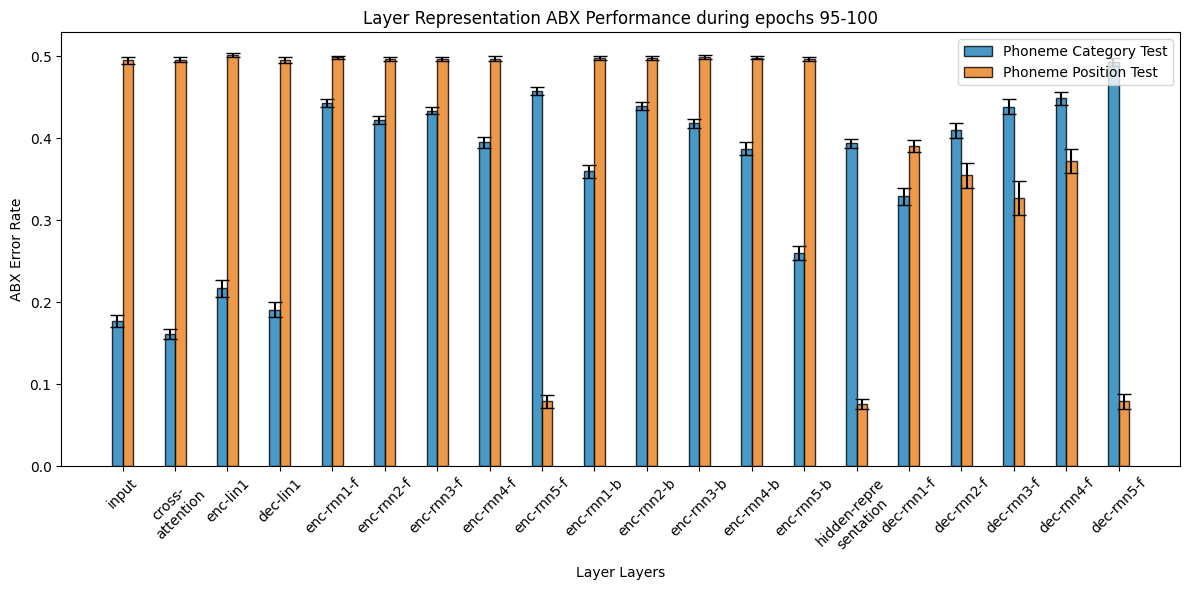

In [58]:
# to_plot_key_order = ["ori", 
#                 # "enc-rnn1-f", 
#                 "enc-rnn5-f", 
#                 # "enc-rnn1-b", 
#                 "enc-rnn5-b", 
#                 "hidrep", 
#                 # "dec-rnn1-f", 
#                 # "dec-rnn5-f", 
#                 "attnout"]
# # to_plot_name_order = ["input-mel-spectrogram", 
# #                 # "first-encoder-LSTM-forward-output", 
# #                 "last-encoder-LSTM-forward-output", 
# #                 # "first-encoder-LSTM-backward-output", 
# #                 "last-encoder-LSTM-backward-output", 
# #                 "final-encoder-output", 
# #                 # "first-decoder-LSTM-output", 
# #                 # "last-decoder-LSTM-output", 
# #                 "cross-attention-output"]

# to_plot_name_order = ["(a) input-mel-spectrogram", 
#                 # "first-encoder-LSTM-forward-output", 
#                 "(b) encoder-LSTM-last-forward-output", 
#                 # "first-encoder-LSTM-backward-output", 
#                 "(c) encoder-LSTM-last-backward-output", 
#                 "(d) encoder-output", 
#                 # "first-decoder-LSTM-output", 
#                 # "last-decoder-LSTM-output", 
#                 "(e) cross-attention-output"
#                 ]

to_plot_key_order = to_plot_key_order
to_plot_name_order = to_plot_name_order

# to_plot_name_order = ["(a)", "(b)", "(c)", "(d)", "(e)"]

reordered_values_pos = [layered_res_pos[key] for key in to_plot_key_order]
reordered_values_cat = [layered_res_cat[key] for key in to_plot_key_order]
ori_wise_name = "oriwise" if ori_wise else ""
y_label_name = "ABX Error Rate againts Input Performance" if ori_wise else "ABX Error Rate"

plot_grouped_bar_errbar_wrap([reordered_values_cat, reordered_values_pos], to_plot_name_order, 
            os.path.join(res_save_dir, f"08-stat-{model_name}-{balance_type}-{strseq_learned_runs}-catpos-{sample_epoch_start}-{sample_epoch_end}-{ori_wise_name}.svg"), 
            [f"{test_plot_name_cat}", f"{test_plot_name_pos}"], 
            plot_label_dict={"xlabel": "Layer Layers", 
                             "ylabel": y_label_name, 
                             "title": f"Layer Representation ABX Performance during epochs {sample_epoch_start}-{sample_epoch_end}"}, 
            max_width=12
            )

## Plot Trajectory

In [49]:
def plot_many_matplotlib(arrs, labels, save_path, plot_label_dict=None, y_range=None, cloud=True):
    """
    Plots the relation between epoch and ABX error rate using matplotlib.

    Parameters:
    - arrs: List of 2D arrays (num_samples, num_epochs).
    - labels: List of labels for the trajectories.
    - save_path: Path to save the resulting plot image.
    - plot_label_dict: Dictionary with 'xlabel', 'ylabel', and 'title' for the plot.
    - y_range: Optional tuple specifying the y-axis range.
    - cloud: If True, shows confidence interval shading.
    """
    if plot_label_dict is None:
        plot_label_dict = {"xlabel": "Epoch", "ylabel": "ABX Error Rate", "title": "ABX Error Rate Across Epochs"}

    n_steps = arrs[0].shape[1]
    mean_trajs = []
    lower_bounds = []
    upper_bounds = []

    # Calculate means and confidence intervals
    for arr in arrs:
        assert arr.shape[1] == n_steps
        mean_traj = np.mean(arr, axis=0)
        sem_arr = stats.sem(arr, axis=0)
        ci_95 = 1.96 * sem_arr  # 95% confidence interval
        upper_bound = mean_traj + ci_95
        lower_bound = mean_traj - ci_95
        mean_trajs.append(mean_traj)
        lower_bounds.append(lower_bound)
        upper_bounds.append(upper_bound)

    # Generate the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    epochs = np.arange(n_steps)

    for idx, (mean_traj, lower_bound, upper_bound, label) in enumerate(zip(mean_trajs, lower_bounds, upper_bounds, labels)):
        if cloud:
            # Confidence interval shading
            ax.fill_between(
                epochs,
                lower_bound,
                upper_bound,
                color=f"C{idx}",
                alpha=0.2,
                label=None  # Label CI once
            )
        # Mean trajectory
        ax.plot(
            epochs,
            mean_traj,
            label=label,
            color=f"C{idx}",
            linewidth=2
        )

    # Customize plot
    ax.set_xlabel(plot_label_dict["xlabel"])
    ax.set_ylabel(plot_label_dict["ylabel"])
    ax.set_title(plot_label_dict["title"])
    # Set legend outside the plot
    # ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1.0), borderaxespad=0.)
    ax.legend(
        loc='upper center',    # Base location at the top-center
        bbox_to_anchor=(0.5, -0.15),  # Shift 0.15 below the axis
        ncol=2,               # Number of columns for legend entries
        frameon=False         # Optional: Remove legend frame
    )
    if y_range:
        ax.set_ylim(y_range)

    # Save and display
    # Adjust layout to make room for the legend
    # plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space on the right for the legend
    plt.subplots_adjust(bottom=0.2)
    plt.savefig(save_path)
    plt.show()


def plot_grouped_many_matplotlib(arrs_list, labels, save_path, test_names, plot_label_dict=None, y_range=None, cloud=True): 
    if plot_label_dict is None:
        plot_label_dict = {"xlabel": "Epoch", "ylabel": "ABX Error Rate", "title": "ABX Error Rate Across Epochs"}
    num_tests = len(arrs_list)
    num_layers = len(labels)
    n_steps = arrs_list[0][0].shape[1]
    mean_trajs_list = []
    lower_bounds_list = []
    upper_bounds_list = []
    linestyles = ['-', '--', '-.', ':']  # solid, dashed, dash-dot, dotted
    # linecolors = ["black", "blue", "orange", "red", "green"]
    linecolors = ["#1a80bb", "#ea801c", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]

    # Calculate means and confidence intervals
    for arrs in arrs_list: 
        mean_trajs = []
        lower_bounds = []
        upper_bounds = []
        for arr in arrs: 
            assert arr.shape[1] == n_steps
            mean_traj = np.mean(arr, axis=0)
            sem_arr = stats.sem(arr, axis=0)
            ci_95 = 1.96 * sem_arr  # 95% confidence interval
            upper_bound = mean_traj + ci_95
            lower_bound = mean_traj - ci_95
            mean_trajs.append(mean_traj)
            lower_bounds.append(lower_bound)
            upper_bounds.append(upper_bound)
        mean_trajs_list.append(mean_trajs)
        lower_bounds_list.append(lower_bounds)
        upper_bounds_list.append(upper_bounds)

    # Generate the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    epochs = np.arange(n_steps)

    for test_idx, (mean_trajs, lower_bounds, upper_bounds, test_name) in enumerate(zip(mean_trajs_list, lower_bounds_list, upper_bounds_list, test_names)): 
        # Create "fake" handles for subtitles
        ax.plot([], [], color="none", label=f"{test_name}")
                # linestyle=linestyles[test_idx % len(linestyles)],  # Line style by layer index
                # linewidth=2)
        for layer_idx, (mean_traj, lower_bound, upper_bound, label) in enumerate(zip(mean_trajs, lower_bounds, upper_bounds, labels)):
            if cloud:
                # Confidence interval shading
                ax.fill_between(
                    epochs,
                    lower_bound,
                    upper_bound,
                    color=linecolors[layer_idx % len(linecolors)],
                    linestyle=linestyles[test_idx % len(linestyles)],  # Line style by layer index
                    alpha=0.2,
                    label=None  # Label CI once
                )
            # Mean trajectory
            ax.plot(
                epochs,
                mean_traj,
                label=label,
                color=linecolors[layer_idx % len(linecolors)],
                linestyle=linestyles[test_idx % len(linestyles)],  # Line style by layer index
                linewidth=2
            )

    # Customize plot
    ax.set_xlabel(plot_label_dict["xlabel"])
    ax.set_ylabel(plot_label_dict["ylabel"])
    ax.set_title(plot_label_dict["title"])
    # Set legend outside the plot
    # ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1.0), borderaxespad=0.)
    ax.legend(
        loc='upper center',    # Base location at the top-center
        bbox_to_anchor=(0.5, -0.15),  # Shift 0.15 below the axis
        ncol=2,               # Number of columns for legend entries
        frameon=False         # Optional: Remove legend frame
    )
    if y_range:
        ax.set_ylim(y_range)

    # Save and display
    # Adjust layout to make room for the legend
    # plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space on the right for the legend
    plt.subplots_adjust(bottom=0.2)
    # plt.savefig(save_path)
    plt.savefig(
        save_path,
        bbox_inches="tight",
        pad_inches=0.05
    )
    plt.show()


In [50]:
train_name = "E_0A"
ts = "1113024340"
eval_dir = os.path.join(model_save_, f"eval-{train_name}-{ts}")
# dim = 16
balance_type = "b"
strseq_learned_runs = "12345"
test_name_pos = "ABXSomethingCrossPhone-first_third-data-AA"
# test_name = "ABXSomething-first-data-AAIY_1"
test_name_cat = "ABXSomething-third-data-AAIY_3"
# test_name = "ABXSomething-third-data-speaker"
# test_name = "ABXSomething-third-data-SSH"
test_plot_name_pos = "Phoneme Position Test"
test_plot_name_cat = "Phoneme Category Test"
# test_plot_name = "Non-linguistic Test"
model_name = f"recon{dim}-phi"
# res_save_dir = os.path.join(eval_dir, f"PLOTS_20250228")
# res_save_dir = os.path.join(f"../PLOTS_20260629")
mk(res_save_dir)
sample_epoch_start = 0
sample_epoch_end = 101
ori_wise = False

## Draw Trajectory

### Collect Pos Data

In [51]:
layered_res_pos = {}
look_for_layer_path = test_name_pos.split("-")[0] + "-" + test_name_pos.split("-")[1] + "-" + test_name_pos.split("-")[2] + "-" + test_name_pos.split("-")[3]
# deal with ori
ori_path = os.path.join(eval_dir, look_for_layer_path, f"07-save-ari-recon64-phi-{balance_type}-{strseq_learned_runs}-ori.npy")
if os.path.exists(ori_path): 
    ori_res = np.load(ori_path)
    ori_res = np.full_like(ori_res, ori_res.mean(axis=1, keepdims=True))
else: 
    raise ValueError("No ori path found.")
for layer in ["hidrep", "attnout", "dec-lin1", "enc-lin1", 
                "dec-rnn1-f", "enc-rnn1-f", "enc-rnn1-b",
                "dec-rnn2-f", "enc-rnn2-f", "enc-rnn2-b", 
                "dec-rnn3-f", "enc-rnn3-f", "enc-rnn3-b", 
                "dec-rnn4-f", "enc-rnn4-f", "enc-rnn4-b", 
                "dec-rnn5-f", "enc-rnn5-f", "enc-rnn5-b", ]: # "enc-lin1", 
    print(f"Processing {balance_type} in layer {layer}...")
    asp_list_epochs = []
    layer_path = os.path.join(eval_dir, look_for_layer_path, 
                                f"07-save-ari-{model_name}-{balance_type}-{strseq_learned_runs}-{layer}.npy")
    if os.path.exists(layer_path): 
        layer_res = np.load(layer_path)
    else: 
        print(f"Warning: {layer_path} not found. ")
        layer_res = np.zeros_like(ori_res)[:, sample_epoch_start:sample_epoch_end]
    if ori_wise: 
        layered_res_pos[layer] = layer_res[:, sample_epoch_start:sample_epoch_end]/ori_res[:, sample_epoch_start:sample_epoch_end]
    else: 
        layered_res_pos[layer] = layer_res[:, sample_epoch_start:sample_epoch_end]
if ori_wise: 
    layered_res_pos["ori"] = ori_res[:, sample_epoch_start:sample_epoch_end]/ori_res[:, sample_epoch_start:sample_epoch_end]
else: 
    layered_res_pos["ori"] = ori_res[:, sample_epoch_start:sample_epoch_end]


layered_res_cat = {}
look_for_layer_path = test_name_cat.split("-")[0] + "-" + test_name_cat.split("-")[1] + "-" + test_name_cat.split("-")[2] + "-" + test_name_cat.split("-")[3]
# deal with ori
ori_path = os.path.join(eval_dir, look_for_layer_path, f"07-save-ari-recon64-phi-{balance_type}-{strseq_learned_runs}-ori.npy")
if os.path.exists(ori_path): 
    ori_res = np.load(ori_path)
    ori_res = np.full_like(ori_res, ori_res.mean(axis=1, keepdims=True))
else: 
    raise ValueError("No ori path found.")
for layer in ["hidrep", "attnout", "dec-lin1", "enc-lin1", 
                "dec-rnn1-f", "enc-rnn1-f", "enc-rnn1-b",
                "dec-rnn2-f", "enc-rnn2-f", "enc-rnn2-b", 
                "dec-rnn3-f", "enc-rnn3-f", "enc-rnn3-b", 
                "dec-rnn4-f", "enc-rnn4-f", "enc-rnn4-b", 
                "dec-rnn5-f", "enc-rnn5-f", "enc-rnn5-b", ]: # "enc-lin1", 
    print(f"Processing {balance_type} in layer {layer}...")
    asp_list_epochs = []
    layer_path = os.path.join(eval_dir, look_for_layer_path, 
                                f"07-save-ari-{model_name}-{balance_type}-{strseq_learned_runs}-{layer}.npy")
    if os.path.exists(layer_path): 
        layer_res = np.load(layer_path)
    else: 
        print(f"Warning: {layer_path} not found. ")
        layer_res = np.zeros_like(ori_res)[:, sample_epoch_start:sample_epoch_end]
    if ori_wise: 
        layered_res_cat[layer] = layer_res[:, sample_epoch_start:sample_epoch_end]/ori_res[:, sample_epoch_start:sample_epoch_end]
    else: 
        layered_res_cat[layer] = layer_res[:, sample_epoch_start:sample_epoch_end]
if ori_wise: 
    layered_res_cat["ori"] = ori_res[:, sample_epoch_start:sample_epoch_end]/ori_res[:, sample_epoch_start:sample_epoch_end]
else: 
    layered_res_cat["ori"] = ori_res[:, sample_epoch_start:sample_epoch_end]

Processing b in layer hidrep...
Processing b in layer attnout...
Processing b in layer dec-lin1...
Processing b in layer enc-lin1...
Processing b in layer dec-rnn1-f...
Processing b in layer enc-rnn1-f...
Processing b in layer enc-rnn1-b...
Processing b in layer dec-rnn2-f...
Processing b in layer enc-rnn2-f...
Processing b in layer enc-rnn2-b...
Processing b in layer dec-rnn3-f...
Processing b in layer enc-rnn3-f...
Processing b in layer enc-rnn3-b...
Processing b in layer dec-rnn4-f...
Processing b in layer enc-rnn4-f...
Processing b in layer enc-rnn4-b...
Processing b in layer dec-rnn5-f...
Processing b in layer enc-rnn5-f...
Processing b in layer enc-rnn5-b...
Processing b in layer hidrep...
Processing b in layer attnout...
Processing b in layer dec-lin1...
Processing b in layer enc-lin1...
Processing b in layer dec-rnn1-f...
Processing b in layer enc-rnn1-f...
Processing b in layer enc-rnn1-b...
Processing b in layer dec-rnn2-f...
Processing b in layer enc-rnn2-f...
Processing b i

### Plot Input Mel  Spectrogram

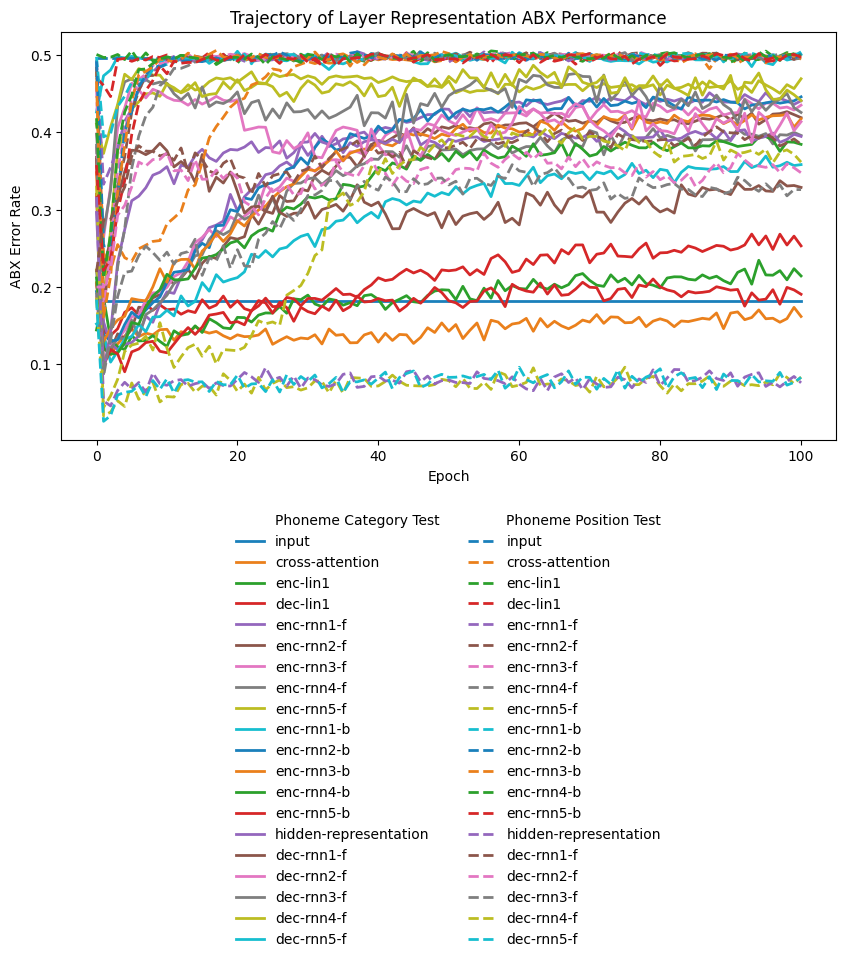

In [52]:
# to_plot_key_order = ["ori", 
#                 # "enc-rnn1-f", 
#                 "enc-rnn5-f", 
#                 # "enc-rnn1-b", 
#                 "enc-rnn5-b", 
#                 "hidrep", 
#                 # "dec-rnn1-f", 
#                 # "dec-rnn5-f", 
#                 "attnout"
#                 ]
# # to_plot_name_order = ["input-mel-spectrogram", 
# #                 # "first-encoder-LSTM-forward-output", 
# #                 "last-encoder-LSTM-forward-output", 
# #                 # "first-encoder-LSTM-backward-output", 
# #                 "last-encoder-LSTM-backward-output", 
# #                 "final-encoder-output", 
# #                 # "first-decoder-LSTM-output", 
# #                 # "last-decoder-LSTM-output", 
# #                 "cross-attention-output"
# #                 ]

# to_plot_name_order = ["(a) input-mel-spectrogram", 
#                 # "first-encoder-LSTM-forward-output", 
#                 "(b) encoder-LSTM-last-forward-output", 
#                 # "first-encoder-LSTM-backward-output", 
#                 "(c) encoder-LSTM-last-backward-output", 
#                 "(d) encoder-output", 
#                 # "first-decoder-LSTM-output", 
#                 # "last-decoder-LSTM-output", 
#                 "(e) cross-attention-output"
#                 ]

to_plot_key_order = to_plot_key_order
to_plot_name_order = to_plot_name_order

# to_plot_name_order = ["(a)", "(b)", "(c)", "(d)", "(e)"]

reordered_values_pos = [layered_res_pos[key] for key in to_plot_key_order]
reordered_values_cat = [layered_res_cat[key] for key in to_plot_key_order]
ori_wise_name = "oriwise" if ori_wise else ""
y_label_name = "ABX Error Rate againts Input Performance" if ori_wise else "ABX Error Rate"

# plot_grouped_bar_errbar_wrap([reordered_values_cat, reordered_values_pos], to_plot_name_order, 
#             os.path.join(res_save_dir, f"08-stat-{model_name}-{balance_type}-{strseq_learned_runs}-catpos-{sample_epoch_start}-{sample_epoch_end}-{ori_wise_name}.png"), 
#             [f"{test_plot_name_cat}", f"{test_plot_name_pos}"], 
#             plot_label_dict={"xlabel": "Intermediate Layers", 
#                              "ylabel": y_label_name, 
#                              "title": f"Intermediate Representation ABX Performance during epochs {sample_epoch_start}-{sample_epoch_end}"}, 
#             )

plot_grouped_many_matplotlib([reordered_values_cat, reordered_values_pos], to_plot_name_order, 
            os.path.join(res_save_dir, f"09-traj-{model_name}-{balance_type}-{strseq_learned_runs}-catpos-{sample_epoch_start}-{sample_epoch_end}-{ori_wise_name}.svg"), 
            [f"{test_plot_name_cat}", f"{test_plot_name_pos}"], 
            plot_label_dict={"xlabel": "Epoch", 
                             "ylabel": y_label_name, 
                             "title": f"Trajectory of Layer Representation ABX Performance"}, 
            cloud=False
            )   # y_range=(0, 0.5)